<a href="https://colab.research.google.com/github/Harini4805/PRODIGY_TrackCode_1/blob/main/DP_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
# Input data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])
# Activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
# Initialize weights
np.random.seed(1)
W1 = np.random.rand(2, 3)
W2 = np.random.rand(3, 1)
lr = 0.1
epochs = 3000
# Training
for _ in range(epochs):
    # Forward pass
    h = sigmoid(np.dot(X, W1))
    output = sigmoid(np.dot(h, W2))
    # Backpropagation
    error = y - output
    d_output = error * output * (1 - output)
    d_hidden = d_output.dot(W2.T) * h * (1 - h)
    # Update weights
    W2 += h.T.dot(d_output) * lr
    W1 += X.T.dot(d_hidden) * lr
# Output
print("Predictions:")
print(np.round(output, 2))


Predictions:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9047 - loss: 0.3108 - val_accuracy: 0.9622 - val_loss: 0.1255
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9549 - loss: 0.1464 - val_accuracy: 0.9716 - val_loss: 0.0960
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9664 - loss: 0.1107 - val_accuracy: 0.9728 - val_loss: 0.0925
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9702 - loss: 0.0949 - val_accuracy: 0.9754 - val_loss: 0.0830
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9737 - loss: 0.0839 - val_accuracy: 0.9767 - val_loss: 0.0820
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9769 - loss: 0.0723 - val_accuracy: 0.9797 - val_loss: 0.0751
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9782 - loss: 0.0680 - val_accuracy: 0.9787 - val_loss: 0.0833
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9799 - loss: 0.06

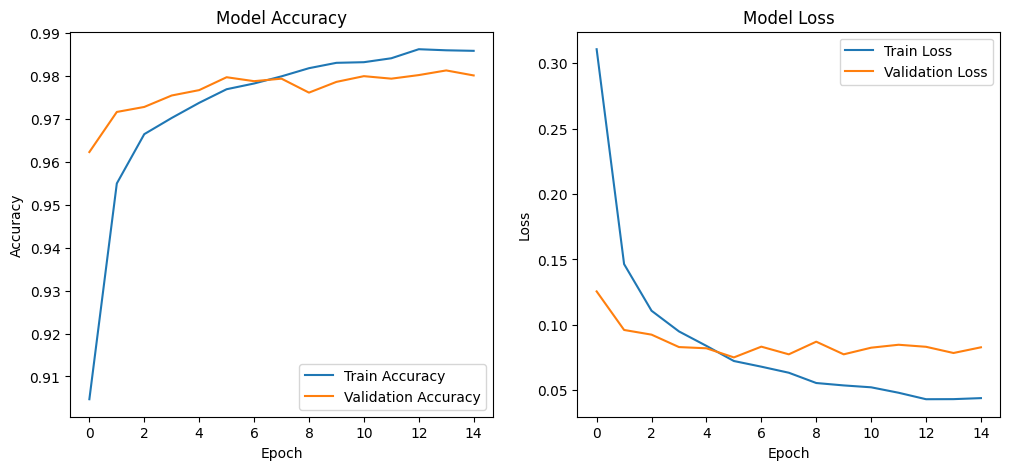

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 5 Predictions: [7 2 1 0 4]
Actual Labels:      [7 2 1 0 4]


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Step 3: Load and Preprocess Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0  # Normalize pixel values
x_test = x_test / 255.0
y_train = to_categorical(y_train, 10)  # One-hot encode labels
y_test = to_categorical(y_test, 10)

# Step 4: Build the MLP Model
model = Sequential([
    Flatten(input_shape=(28,28)),   # Flatten images to 1D
    Dense(256, activation='relu'),  # First hidden layer with 256 neurons
    Dropout(0.3),                   # Dropout to reduce overfitting
    Dense(128, activation='relu'),  # Second hidden layer with 128 neurons
    Dropout(0.2),
    Dense(10, activation='softmax') # Output layer for 10 classes
])



# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Step 6: Train the Model
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2)
# Step 7: Evaluate the Model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Step 8: Plot Training History
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 9 (Optional): Predictions
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
print("First 5 Predictions:", predicted_classes[:5])
print("Actual Labels:     ", np.argmax(y_test[:5], axis=1))


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


# Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Function to train model
def run_model(act):
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation=act),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5, batch_size=32, verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print(act.upper(), "Accuracy:", round(acc*100,2), "%")

# Run comparison
run_model('relu')
run_model('sigmoid')
run_model('tanh')


RELU Accuracy: 97.8 %
SIGMOID Accuracy: 97.04 %
TANH Accuracy: 97.79 %


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0588 - val_loss: 0.0319
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0259 - val_loss: 0.0207
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0180 - val_loss: 0.0150
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0135 - val_loss: 0.0115
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0105 - val_loss: 0.0091
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0085 - val_loss: 0.0075
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0072 - val_loss: 0.0065
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0057 - val_loss: 0.0053
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0053 - val_loss: 0.0049
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


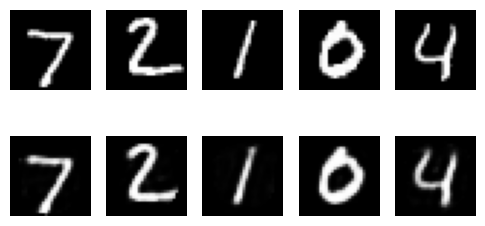

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# Load and preprocess data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
# Build simple autoencoder
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(64, activation='relu'),      # Encoder
    Dense(784, activation='sigmoid'),  # Decoder
    Reshape((28,28))
])
# Compile model
model.compile(optimizer='adam', loss='mse')
# Train model
model.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
# Reconstruct images
reconstructed = model.predict(x_test)
# Display original and reconstructed images
plt.figure(figsize=(6,3))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.axis('off')
plt.show()


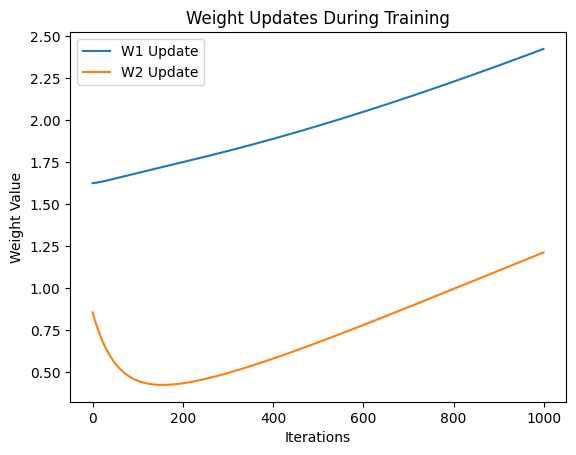

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Input data (AND gate)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# Initialize weights
np.random.seed(1)
W1 = np.random.randn(2,2)
W2 = np.random.randn(2,1)
lr = 0.1
epochs = 1000

# To store weight updates
w1_updates = []
w2_updates = []

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training loop
for _ in range(epochs):
    # ----- Forward Propagation -----
    z1 = np.dot(X, W1)
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2)
    output = sigmoid(z2)

    # ----- Backpropagation -----
    error = y - output
    d_output = error * sigmoid_derivative(output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(a1)

    # ----- Weight Updates -----
    W2 += a1.T.dot(d_output) * lr
    W1 += X.T.dot(d_hidden) * lr

    w1_updates.append(W1[0,0])
    w2_updates.append(W2[0,0])

# Plot weight updates
plt.plot(w1_updates, label='W1 Update')
plt.plot(w2_updates, label='W2 Update')
plt.xlabel('Iterations')
plt.ylabel('Weight Value')
plt.title('Weight Updates During Training')
plt.legend()
plt.show()


In [6]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize image data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to categorical format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)




# Function to create model
def build_model(loss_function):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss=loss_function,
                  metrics=['accuracy'])
    return model

# -------------------------------
# Train model using MSE Loss
# -------------------------------
print("Training with Mean Squared Error (MSE)")
model_mse = build_model('mse')
model_mse.fit(X_train, y_train, epochs=5, batch_size=128)

mse_loss, mse_accuracy = model_mse.evaluate(X_test, y_test)
print("MSE Test Accuracy:", mse_accuracy)

# -------------------------------
# Train model using Cross-Entropy Loss
# -------------------------------
print("\nTraining with Categorical Cross-Entropy")
model_ce = build_model('categorical_crossentropy')
model_ce.fit(X_train, y_train, epochs=5, batch_size=128)

ce_loss, ce_accuracy = model_ce.evaluate(X_test, y_test)
print("Cross-Entropy Test Accuracy:", ce_accuracy)


Training with Mean Squared Error (MSE)
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9012 - loss: 0.0156
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9521 - loss: 0.0076
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9652 - loss: 0.0057
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9731 - loss: 0.0045
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9779 - loss: 0.0037
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.0046
MSE Test Accuracy: 0.9700999855995178

Training with Categorical Cross-Entropy
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9020 - loss: 0.3559
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9530 - loss: 0.1654
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9651 - loss: 0.1208
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9726 - loss: 0.0935
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [1]:
!pip install scikeras # Install scikeras to resolve ModuleNotFoundError

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier # Changed import to scikeras
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Step 3: Load and preprocess data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train/255.0, X_test/255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Step 4: Function to create model
def create_model(learning_rate=0.001, num_layers=1, neurons=128):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))

    for _ in range(num_layers):
        model.add(Dense(neurons, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# Step 5: Wrap model for sklearn
# For scikeras.wrappers.KerasClassifier, 'model' argument is used instead of 'build_fn'
model = KerasClassifier(model=create_model, epochs=5, verbose=0)

# Step 6: Define hyperparameter grid
# Hyperparameters for the Keras model must be prefixed with 'model__'
# Hyperparameters for the fit method (like batch_size) must be prefixed with 'fit__'
param_grid = {
    'fit__batch_size': [64, 128],
    'model__learning_rate': [0.001, 0.01],
    'model__num_layers': [1, 2],
    'model__neurons': [64, 128]
}
# Step 7: Grid Search
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

# Step 8: Display best parameters and accuracy
print("Best Hyperparameters:", grid_result.best_params_)
print("Best Accuracy: {:.2f}%".format(grid_result.best_score_*100))
# Step 9: Evaluate best model on test set
# For scikeras.wrappers.KerasClassifier, the underlying Keras model is accessed via 'model_'
best_model_keras = grid_result.best_estimator_.model_
loss, test_acc = best_model_keras.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(test_acc*100))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `inpu

Best Hyperparameters: {'fit__batch_size': 64, 'model__learning_rate': 0.001, 'model__neurons': 128, 'model__num_layers': 2}
Best Accuracy: 96.93%
Test Accuracy: 97.23%


In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Step 2: Load and preprocess data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Step 4: Build simple CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 5: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

# Step 6: Train the model using augmented data
model.fit(datagen.flow(x_train, y_train, batch_size=64),
          epochs=10,
          validation_data=(x_test, y_test))

# Evaluate performance
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy with Data Augmentation: {accuracy:.4f}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 367s 2us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - accuracy: 0.3996 - loss: 1.6712 - val_accuracy: 0.5019 - val_loss: 1.3913
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.4957 - loss: 1.4241 - val_accuracy: 0.5405 - val_loss: 1.3092
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.5257 - loss: 1.3437 - val_accuracy: 0.5658 - val_loss: 1.2522
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.5441 - loss: 1.2931 - val_accuracy: 0.5932 - val_loss: 1.1791
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.5551 - loss: 1.2569 - val_accuracy: 0.5817 - val_loss: 1.2001
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.5700 - loss: 1.2317 - val_accuracy: 0.6150 - val_loss: 1.0961
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.5771 - loss: 1.2005 - val_accuracy: 0.6254 - val_loss: 1.0596
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.5837 - loss: 1.1846 - 

In [2]:

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Step 2: Load IMDB dataset
vocab_size = 5000
maxlen = 100


(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences to same length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Step 3: Build RNN Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

# Step 4: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train Model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Step 6: Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.7014 - loss: 0.5510 - val_accuracy: 0.8148 - val_loss: 0.4159
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8532 - loss: 0.3492 - val_accuracy: 0.8348 - val_loss: 0.3850
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9017 - loss: 0.2504 - val_accuracy: 0.8052 - val_loss: 0.4322
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9456 - loss: 0.1546 - val_accuracy: 0.8190 - val_loss: 0.4924
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9763 - loss: 0.0801 - val_accuracy: 0.8058 - val_loss: 0.5777
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8104 - loss: 0.5675
Test Accuracy: 0.8104
